# Evaluating VLM Robustness to Background and Context Changes

**ECE 176 Project** — Based on proposal: *Evaluating the Robustness of Vision-Language Models to Background and Context Changes*.

This notebook implements:
1. **Baseline evaluation** of a pre-trained VLM (CLIP) on original images with fixed object-level prompts.
2. **Background perturbations**: Gaussian blur, masking, and partial cropping (foreground preserved via COCO bounding boxes).
3. **Quantitative analysis**: accuracy and image–text similarity before vs after modification.
4. **Qualitative analysis**: inspection of failure cases.

## 1. Setup and Imports

In [10]:
# Uncomment and run once if dependencies are missing:
# !pip install torch torchvision transformers Pillow opencv-python-headless pycocotools tqdm matplotlib

import os
import json
import random
from pathlib import Path
from typing import Optional, Tuple, List, Dict, Any

import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms
from tqdm import tqdm
import matplotlib.pyplot as plt

# Set seeds for reproducibility
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [11]:
# Configuration
CONFIG = {
    "coco_root": os.environ.get("COCO_ROOT", "./data/coco"),
    "coco_image_subdir": "val2017",  # subdir under coco_root where images live (e.g. val2017)
    "coco_ann_file": os.environ.get("COCO_ANN", "./data/coco/annotations/instances_val2017.json"),
    "categories": ["boat", "airplane", "horse"],  # Strong background-dependent categories
    "max_images_per_category": 50,  # Limit for quick runs; set higher for full eval
    "clip_model": "openai/clip-vit-base-patch32",
    "image_size": 224,
    "perturbation": {
        "gaussian_blur_radius": 25,
        "mask_fill_value": 128,
        "crop_padding": 0.1,
        "feather_sigma": 12.0,        # Soft mask boundary (0 = hard edge)
        "use_rembg": False,           # True: use rembg for foreground when no COCO seg (pip install rembg)
    },
}

## 2. Load Vision-Language Model (CLIP)

We use **CLIP** (Radford et al., ICML 2021) as the pre-trained VLM. Model parameters stay fixed; we only run inference.

In [12]:
from transformers import CLIPProcessor, CLIPModel

def load_clip(model_name: str = "openai/clip-vit-base-patch32"):
    model = CLIPModel.from_pretrained(model_name).to(device).eval()
    processor = CLIPProcessor.from_pretrained(model_name)
    return model, processor

clip_model, clip_processor = load_clip(CONFIG["clip_model"])
print(f"Loaded {CONFIG['clip_model']}")

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 2001.10it/s, Materializing param=visual_projection.weight]                                
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded openai/clip-vit-base-patch32


In [13]:
def get_image_text_similarity(
    model: CLIPModel,
    processor: CLIPProcessor,
    images: List[Image.Image],
    text_prompts: List[str],
    batch_size: int = 32,
) -> np.ndarray:
    """Compute image-text similarity (cosine) for each image against all prompts. Returns (N_images, N_prompts)."""
    all_sims = []
    for i in range(0, len(images), batch_size):
        batch_imgs = images[i : i + batch_size]
        batch_text = text_prompts
        inputs = processor(
            text=batch_text,
            images=batch_imgs,
            return_tensors="pt",
            padding=True,
            truncation=True,
        ).to(device)
        with torch.no_grad():
            outputs = model(**inputs)
            logits_per_image = outputs.logits_per_image  # (batch, num_text)
            sim = F.softmax(logits_per_image, dim=-1).cpu().numpy()
        all_sims.append(sim)
    return np.vstack(all_sims)

def accuracy_from_similarity(similarity: np.ndarray, label_indices: np.ndarray) -> float:
    """Accuracy when label_indices[i] is the correct prompt index for image i."""
    preds = np.argmax(similarity, axis=1)
    return (preds == label_indices).mean()

## 3. Background Perturbations

We modify the **background** while keeping the **foreground object** intact. Using a **foreground mask** (not just a rectangle) gives realistic results:

- **Foreground mask**: From **COCO segmentation** when available, else **rembg** (AI segmentation), else **bbox** with **feathered** edges so the boundary is soft.
- **Gaussian blur**: Blur only the background and blend with a soft mask (no hard rectangle).
- **Masking**: Replace background with a constant using the same mask.
- **Partial crop**: Crop to the object region (bbox is fine here).

In [14]:
import cv2

def bbox_to_xyxy(bbox: List[float], img_w: int, img_h: int) -> Tuple[int, int, int, int]:
    """COCO bbox [x, y, w, h] -> (x1, y1, x2, y2) clipped to image."""
    x, y, w, h = bbox
    x1 = max(0, int(x))
    y1 = max(0, int(y))
    x2 = min(img_w, int(x + w))
    y2 = min(img_h, int(y + h))
    return x1, y1, x2, y2

def get_foreground_mask(sample: Dict, img_shape: Tuple[int, ...], use_rembg: bool = False) -> np.ndarray:
    """
    Get foreground mask (H, W) float in [0,1]. Prefer: 1) COCO segmentation, 2) rembg, 3) bbox.
    """
    h, w = img_shape[:2]
    # 1) COCO segmentation (when available from load_coco_subset)
    seg = sample.get("segmentation")
    if seg is not None and sample.get("image_height") and sample.get("image_width"):
        try:
            from pycocotools import mask as mask_util
            if isinstance(seg, list):
                # polygon format
                rles = mask_util.frPyObjects(seg, sample["image_height"], sample["image_width"])
                rle = mask_util.merge(rles)
            else:
                rle = seg
            mask = mask_util.decode(rle)
            if mask.ndim == 3:
                mask = mask.max(axis=2)
            if mask.shape[0] != h or mask.shape[1] != w:
                mask = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)
            return (mask > 0).astype(np.float32)
        except Exception:
            pass
    # 2) rembg (AI foreground segmentation) - optional, pip install rembg
    if use_rembg:
        try:
            from rembg import remove as rembg_remove
            from io import BytesIO
            with open(sample["image_path"], "rb") as f:
                out = rembg_remove(f.read())
            rembg_img = np.array(Image.open(BytesIO(out)).convert("RGBA"))
            mask = (rembg_img[:, :, 3] > 128).astype(np.float32)
            if mask.shape[0] != h or mask.shape[1] != w:
                mask = cv2.resize(mask, (w, h), interpolation=cv2.INTER_LINEAR)
            return mask
        except ImportError:
            pass
    # 3) Fallback: bbox as rectangle
    x1, y1, x2, y2 = bbox_to_xyxy(sample["bbox"], w, h)
    mask = np.zeros((h, w), dtype=np.float32)
    mask[y1:y2, x1:x2] = 1.0
    return mask

def feather_mask(mask: np.ndarray, sigma: float = 15.0) -> np.ndarray:
    """Soft mask boundary (float [0,1]) so blur/mask blend smoothly."""
    if sigma <= 0:
        return mask
    blurred = cv2.GaussianBlur(mask, (0, 0), sigma)
    return np.clip(blurred, 0, 1).astype(np.float32)

def perturb_background_blur(
    img: np.ndarray,
    fg_mask: np.ndarray,
    kernel_size: int = 25,
    feather_sigma: float = 12.0,
) -> np.ndarray:
    """Blur background and blend with foreground using a soft mask (no hard edges)."""
    h, w = img.shape[:2]
    if kernel_size % 2 == 0:
        kernel_size += 1
    blurred = cv2.GaussianBlur(img, (kernel_size, kernel_size), 0)
    m = feather_mask(fg_mask, feather_sigma)
    out = (img.astype(np.float32) * m[:, :, None] + blurred.astype(np.float32) * (1 - m[:, :, None]))
    return np.clip(out, 0, 255).astype(np.uint8)

def perturb_background_mask(
    img: np.ndarray,
    fg_mask: np.ndarray,
    fill_value: int = 128,
    feather_sigma: float = 12.0,
) -> np.ndarray:
    """Replace background with constant color; soft blend at boundary."""
    m = feather_mask(fg_mask, feather_sigma)
    bg = np.full_like(img, fill_value)
    out = (img.astype(np.float32) * m[:, :, None] + bg.astype(np.float32) * (1 - m[:, :, None]))
    return np.clip(out, 0, 255).astype(np.uint8)

def perturb_crop_to_object(
    img: np.ndarray,
    bbox: List[float],
    padding_frac: float = 0.1,
) -> np.ndarray:
    """Crop image to a region around the bbox (reduces background)."""
    h, w = img.shape[:2]
    x1, y1, x2, y2 = bbox_to_xyxy(bbox, w, h)
    bw, bh = x2 - x1, y2 - y1
    pad_w = int(bw * padding_frac)
    pad_h = int(bh * padding_frac)
    cx1 = max(0, x1 - pad_w)
    cy1 = max(0, y1 - pad_h)
    cx2 = min(w, x2 + pad_w)
    cy2 = min(h, y2 + pad_h)
    return img[cy1:cy2, cx1:cx2]

**How the foreground is defined (no more “pure bbox”):**
- **COCO**: When the annotation has `segmentation` (polygon/RLE), we decode it to a precise object mask.
- **rembg**: If `use_rembg: True` in config and the package is installed, we use AI to segment the foreground (works without COCO).
- **Fallback**: Rectangle bbox with **feathered** edges (`feather_sigma`) so the boundary is soft and the result looks natural.

## 4. Load MS COCO Subset

We select images containing **boat**, **airplane**, and **horse** (categories with strong background dependence). Each sample has one primary bbox per image for perturbation.

In [15]:
def load_coco_subset(
    coco_root: str,
    ann_file: str,
    categories: List[str],
    max_per_category: int,
    image_subdir: str = "val2017",
) -> List[Dict[str, Any]]:
    """
    Returns list of dicts: {
        "image_path": str,
        "bbox": [x, y, w, h],
        "category_name": str,
        "category_id": int,
        "image_id": int,
    }
    """
    try:
        from pycocotools.coco import COCO
    except ImportError:
        raise ImportError("Install pycocotools: pip install pycocotools")

    coco = COCO(ann_file)
    cat_ids = coco.getCatIds(catNms=categories)
    img_ids = coco.getImgIds(catIds=cat_ids)
    samples = []

    for im_id in img_ids:
        ann_ids = coco.getAnnIds(imgIds=im_id, catIds=cat_ids)
        anns = coco.loadAnns(ann_ids)
        if not anns:
            continue
        info = coco.loadImgs(im_id)[0]
        fname = info["file_name"]
        img_path = os.path.join(coco_root, image_subdir, fname) if image_subdir else os.path.join(coco_root, fname)
        if not os.path.isfile(img_path):
            continue
        # Use annotation with largest area as primary object
        ann = max(anns, key=lambda a: a.get("area", 0))
        cat = coco.loadCats(ann["category_id"])[0]
        cat_name = cat["name"]
        if cat_name not in categories:
            continue
        rec = {
            "image_path": img_path,
            "bbox": ann["bbox"],
            "category_name": cat_name,
            "category_id": ann["category_id"],
            "image_id": im_id,
            "image_height": info["height"],
            "image_width": info["width"],
        }
        if ann.get("segmentation"):
            rec["segmentation"] = ann["segmentation"]
        samples.append(rec)

    # Limit per category
    by_cat = {}
    for s in samples:
        c = s["category_name"]
        by_cat.setdefault(c, []).append(s)
    out = []
    for c in categories:
        out.extend(by_cat.get(c, [])[:max_per_category])
    random.shuffle(out)
    return out

In [16]:
def create_demo_samples(
    categories: List[str],
    n_per_category: int = 3,
    image_size: Tuple[int, int] = (336, 336),
    demo_dir: str = "./demo_coco_images",
) -> List[Dict[str, Any]]:
    """
    Create synthetic demo images when COCO is not available.
    Saves images to demo_dir and returns a list of sample dicts (same format as load_coco_subset).
    """
    os.makedirs(demo_dir, exist_ok=True)
    samples = []
    # COCO category IDs for boat=9, airplane=5, horse=17
    cat_ids = {"boat": 9, "airplane": 5, "horse": 17}
    for ci, cat in enumerate(categories):
        for k in range(n_per_category):
            # Simple synthetic image: gradient + a central "object" rectangle (so bbox is meaningful)
            arr = np.zeros((*image_size, 3), dtype=np.uint8)
            arr[:, :, 0] = 30 + (ci * 80) % 200
            arr[:, :, 1] = 80 + (k * 40) % 120
            arr[:, :, 2] = 120 + ((ci + k) * 30) % 100
            # Central rectangle as "object"
            h, w = image_size
            margin = 4
            x1, y1 = w // 4 + margin, h // 4 + margin
            x2, y2 = 3 * w // 4 - margin, 3 * h // 4 - margin
            arr[y1:y2, x1:x2] = [200, 200, 200]
            bbox = [float(x1), float(y1), float(x2 - x1), float(y2 - y1)]
            fname = f"{cat}_{k:02d}.jpg"
            path = os.path.join(demo_dir, fname)
            Image.fromarray(arr).save(path)
            samples.append({
                "image_path": path,
                "bbox": bbox,
                "category_name": cat,
                "category_id": cat_ids.get(cat, ci + 1),
                "image_id": len(samples),
            })
    return samples

In [17]:
# Load COCO subset, or use demo images when COCO is not available
USE_DEMO_WHEN_NO_COCO = True  # Set False to skip evaluation when COCO is missing
COCO_SAMPLES = []
if os.path.isfile(CONFIG["coco_ann_file"]) and os.path.isdir(CONFIG["coco_root"]):
    COCO_SAMPLES = load_coco_subset(
        CONFIG["coco_root"],
        CONFIG["coco_ann_file"],
        CONFIG["categories"],
        CONFIG["max_images_per_category"],
        image_subdir=CONFIG.get("coco_image_subdir", "val2017"),
    )
    print(f"Loaded {len(COCO_SAMPLES)} COCO samples.")
else:
    print("COCO data not found. Set COCO_ROOT and COCO_ANN or download COCO val2017 and annotations.")
    print("See: https://cocodataset.org/#download")
    if USE_DEMO_WHEN_NO_COCO:
        COCO_SAMPLES = create_demo_samples(CONFIG["categories"], n_per_category=3)
        print(f"Using {len(COCO_SAMPLES)} demo samples (synthetic images in ./demo_coco_images/).")
    else:
        print("Using empty sample list; later cells will skip evaluation.")

COCO data not found. Set COCO_ROOT and COCO_ANN or download COCO val2017 and annotations.
See: https://cocodataset.org/#download
Using 9 demo samples (synthetic images in ./demo_coco_images/).


## 5. Fixed Text Prompts and Label Index

Prompt wording is kept **consistent** across experiments so that changes can be attributed to visual input.

In [18]:
# Object-level text prompts (order must match CONFIG["categories"])
TEXT_PROMPTS = ["a photo of a boat", "a photo of an airplane", "a photo of a horse"]
CAT_TO_IDX = {c: i for i, c in enumerate(CONFIG["categories"])}
assert TEXT_PROMPTS.__len__() == len(CONFIG["categories"])

## 6. Baseline Evaluation (Original Images)

Measure model performance on **original** images using the fixed prompts.

In [19]:
def run_baseline_evaluation(samples: List[Dict]) -> Tuple[float, np.ndarray, List[float]]:
    """Returns (accuracy, similarity matrix, per-image max similarity)."""
    if not samples:
        return 0.0, np.array([]), []

    images = []
    labels = []
    for s in samples:
        img = Image.open(s["image_path"]).convert("RGB")
        images.append(img)
        labels.append(CAT_TO_IDX[s["category_name"]])

    sim = get_image_text_similarity(clip_model, clip_processor, images, TEXT_PROMPTS)
    acc = accuracy_from_similarity(sim, np.array(labels))
    max_sim = [sim[i].max() for i in range(len(images))]
    return acc, sim, max_sim

if COCO_SAMPLES:
    baseline_acc, baseline_sim, baseline_max_sim = run_baseline_evaluation(COCO_SAMPLES)
    print(f"Baseline accuracy: {baseline_acc:.4f}")
    print(f"Baseline mean max similarity: {np.mean(baseline_max_sim):.4f}")
else:
    baseline_acc, baseline_sim, baseline_max_sim = 0.0, np.array([]), []
    print("Skipped baseline (no samples).")

Baseline accuracy: 0.2222
Baseline mean max similarity: 0.4386


## 7. Background-Perturbed Evaluation

Apply each perturbation type and measure accuracy and similarity again.

In [20]:
def load_and_perturb(
    sample: Dict,
    perturbation_type: str,
    config: dict,
) -> Image.Image:
    """Load image and return perturbed PIL Image (RGB). Uses foreground mask (COCO seg / rembg / feathered bbox)."""
    img = np.array(Image.open(sample["image_path"]).convert("RGB"))
    bbox = sample["bbox"]
    pert = config["perturbation"]
    if perturbation_type == "blur":
        fg_mask = get_foreground_mask(sample, img.shape, use_rembg=pert.get("use_rembg", False))
        img = perturb_background_blur(
            img, fg_mask,
            kernel_size=pert["gaussian_blur_radius"],
            feather_sigma=pert.get("feather_sigma", 12.0),
        )
    elif perturbation_type == "mask":
        fg_mask = get_foreground_mask(sample, img.shape, use_rembg=pert.get("use_rembg", False))
        img = perturb_background_mask(
            img, fg_mask,
            fill_value=pert["mask_fill_value"],
            feather_sigma=pert.get("feather_sigma", 12.0),
        )
    elif perturbation_type == "crop":
        img = perturb_crop_to_object(img, bbox, padding_frac=pert["crop_padding"])
    else:
        raise ValueError(perturbation_type)
    return Image.fromarray(img)

def run_perturbed_evaluation(
    samples: List[Dict],
    perturbation_type: str,
) -> Tuple[float, np.ndarray, List[float]]:
    """Returns (accuracy, similarity matrix, per-image max similarity)."""
    if not samples:
        return 0.0, np.array([]), []

    images = []
    labels = []
    for s in tqdm(samples, desc=f"Perturb ({perturbation_type})"):
        img = load_and_perturb(s, perturbation_type, CONFIG)
        images.append(img)
        labels.append(CAT_TO_IDX[s["category_name"]])

    sim = get_image_text_similarity(clip_model, clip_processor, images, TEXT_PROMPTS)
    acc = accuracy_from_similarity(sim, np.array(labels))
    max_sim = [sim[i].max() for i in range(len(images))]
    return acc, sim, max_sim

In [21]:
results = {}
if COCO_SAMPLES:
    for ptype in ["blur", "mask", "crop"]:
        acc, sim, max_sim = run_perturbed_evaluation(COCO_SAMPLES, ptype)
        results[ptype] = {"accuracy": acc, "similarity": sim, "max_sim": max_sim}
        print(f"{ptype}: accuracy = {acc:.4f}, mean max sim = {np.mean(max_sim):.4f}")
else:
    print("Skipped perturbed evaluation (no samples).")

Perturb (blur): 100%|██████████| 9/9 [00:00<00:00, 108.43it/s]


blur: accuracy = 0.4444, mean max sim = 0.4464


Perturb (mask): 100%|██████████| 9/9 [00:00<00:00, 422.10it/s]


mask: accuracy = 0.3333, mean max sim = 0.4548


Perturb (crop): 100%|██████████| 9/9 [00:00<00:00, 1463.19it/s]


crop: accuracy = 0.3333, mean max sim = 0.4958


## 8. Quantitative Analysis

Compare accuracy and similarity scores across baseline vs each perturbation type.

Condition      Accuracy   Mean max sim
--------------------------------------
Baseline         0.2222         0.4386
blur             0.4444         0.4464
mask             0.3333         0.4548
crop             0.3333         0.4958


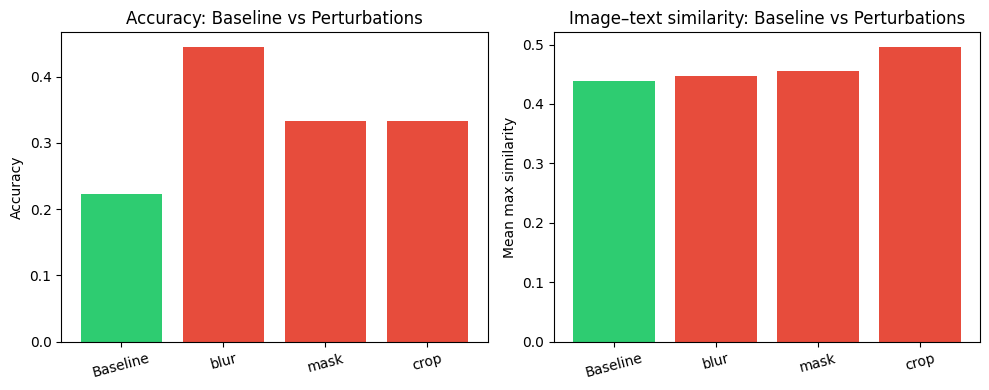

In [22]:
if COCO_SAMPLES and results:
    # Summary table
    rows = [("Baseline", baseline_acc, np.mean(baseline_max_sim))]
    for ptype, data in results.items():
        rows.append((ptype, data["accuracy"], np.mean(data["max_sim"])))
    print(f"{'Condition':<12} {'Accuracy':>10} {'Mean max sim':>14}")
    print("-" * 38)
    for name, acc, msim in rows:
        print(f"{name:<12} {acc:>10.4f} {msim:>14.4f}")

    # Bar plot: accuracy
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    names = ["Baseline"] + list(results.keys())
    accs = [baseline_acc] + [results[k]["accuracy"] for k in results]
    axes[0].bar(names, accs, color=["#2ecc71"] + ["#e74c3c"] * 3)
    axes[0].set_ylabel("Accuracy")
    axes[0].set_title("Accuracy: Baseline vs Perturbations")
    axes[0].tick_params(axis="x", rotation=15)

    sims = [np.mean(baseline_max_sim)] + [np.mean(results[k]["max_sim"]) for k in results]
    axes[1].bar(names, sims, color=["#2ecc71"] + ["#e74c3c"] * 3)
    axes[1].set_ylabel("Mean max similarity")
    axes[1].set_title("Image–text similarity: Baseline vs Perturbations")
    axes[1].tick_params(axis="x", rotation=15)
    plt.tight_layout()
    plt.show()
else:
    print("No results to plot. Run with COCO data first.")

## 9. Qualitative Analysis: Failure Cases

Inspect examples where the model was correct on the original image but **wrong** after a perturbation (or vice versa).

In [23]:
def find_failure_cases(
    samples: List[Dict],
    baseline_sim: np.ndarray,
    perturbed_sim: np.ndarray,
    perturbation_name: str,
    top_k: int = 5,
) -> List[Tuple[int, bool]]:
    """
    Find indices where baseline predicted correctly but perturbed wrong (or baseline wrong, perturbed correct).
    Returns list of (sample_idx, baseline_correct).
    """
    if baseline_sim.size == 0 or perturbed_sim.size == 0:
        return []
    labels = np.array([CAT_TO_IDX[s["category_name"]] for s in samples])
    base_pred = np.argmax(baseline_sim, axis=1)
    pert_pred = np.argmax(perturbed_sim, axis=1)
    base_correct = base_pred == labels
    pert_correct = pert_pred == labels
    # Failures: correct on baseline, wrong on perturbed
    failures = np.where(base_correct & ~pert_correct)[0]
    return [(int(i), True) for i in failures[:top_k]]

if COCO_SAMPLES and results:
    # Show failure cases for first perturbation type
    ptype = list(results.keys())[0]
    failures = find_failure_cases(
        COCO_SAMPLES, baseline_sim, results[ptype]["similarity"], ptype, top_k=3
    )
    if failures:
        n_show = min(3, len(failures))
        fig, axes = plt.subplots(n_show, 2, figsize=(8, 4 * n_show))
        if n_show == 1:
            axes = axes.reshape(1, -1)
        for row, (idx, _) in enumerate(failures[:n_show]):
            orig = Image.open(COCO_SAMPLES[idx]["image_path"]).convert("RGB")
            pert = load_and_perturb(COCO_SAMPLES[idx], ptype, CONFIG)
            axes[row, 0].imshow(orig)
            axes[row, 0].set_title(f"Original (true: {COCO_SAMPLES[idx]['category_name']})")
            axes[row, 0].axis("off")
            axes[row, 1].imshow(pert)
            axes[row, 1].set_title(f"After {ptype}")
            axes[row, 1].axis("off")
        plt.suptitle("Example failure cases: correct on original, wrong after perturbation")
        plt.tight_layout()
        plt.show()
    else:
        print("No failure cases found for this perturbation (or too few samples).")
else:
    print("No samples or results for qualitative analysis.")

No failure cases found for this perturbation (or too few samples).


## 10. Summary and Next Steps

- **Baseline vs perturbations**: Lower accuracy and similarity after background blur, masking, or cropping indicate that the model relies on contextual/background cues.
- **Optional extensions** (not implemented in this notebook):
  - **ImageNet-R / ImageNet-A**: Load OOD data and run the same evaluation (no extra perturbations) to measure robustness under distribution shift.
  - **ObjectNet / CLEVR**: Object-centric datasets as a control; compare behavior when background shortcuts are reduced.
  - **Background replacement**: Replace background with an unrelated scene (requires segmentation, e.g. rembg or SAM).
  - **Other VLMs**: Run the same pipeline with LLaVA, BLIP-2, or other vision-language models for comparison.